Feynman diagrams integration

Let's calculate density of states:

$$\rho_{\eta}(\omega) =   \int_{BZ}  \frac{d^{3}k}{(2 \pi)^{3}} \frac{1}{\pi} \frac{\eta}{(\omega - \epsilon(\mathbf{k}))^{2} + \eta^{2}}$$

nearest-neighbour 3D cubic tight binding band $\epsilon (\mathbf{k}) = -2 b (\cos(k_{x}) + \cos(k_{y}) + \cos(k_{z}))$

Brillouin zone $k_{x}, k_{y}, k_{z} \in [- \pi, \pi]$

band range $\epsilon \in [-6b, 6b]$

Scalar DOS: $f_{\eta}(\omega, k_{x}, k_{y}, k_{z}) = \frac{1}{\pi} \frac{\eta}{(\omega - \epsilon(k_{x},k_{y}, k_{z}))^{2} + \eta^{2}}$

For a fixed $\omega$ calculate $\rho_{\eta}(\omega)=\int_{-\pi}^{\pi} \int_{-\pi}^{\pi} \int_{-\pi}^{\pi} \frac{dk_{x} dk_{y} dk_{z}}{(2\pi)^{3}} f_{\eta}(\omega, k_{x}, k_{y}, k_{z})$

First quadraure approximation: 

We select a uniform grid $k_{j} = - \pi + \frac{2\pi j}{N}, \quad j= 0, \dots, N-1$ and approximate:

$$\rho_{\eta} (\omega) \approx \frac{1}{N^{3}} \sum_{j_{x}, j_{y}, j_{z}} \frac{1}{\pi} \frac{\eta}{(\omega - \epsilon_{j_{x}, j_{y}, j_{z}})^{2} + \eta^{2}}.$$

In [13]:
import numpy as np
import numba

@numba.njit
def epsilon_from_cos(b, cx, cy, cz):
    return -2.0 * b * (cx + cy + cz)

@numba.njit
def quadrature(N, b, eta, omega):
    # Numba-friendly replacement for:
    # kj = np.linspace(-np.pi, np.pi, N, endpoint=False)
    kj = np.arange(N) * (2.0 * np.pi / N) - np.pi
    cos_k = np.cos(kj)
    sum_of_parts, compensation = 0.0, 0.0
    for i in range(N):
        cx = cos_k[i]
        for j in range(N):
            cy = cos_k[j]
            for l in range(N):
                cz = cos_k[l]
                eps = epsilon_from_cos(b, cx, cy, cz)
                denominator = (omega - eps)**2 + eta**2
            
                # Kahan summation (for accumulation accuracy, floating point error) 
                term = 1.0 / denominator
                y = term - compensation
                t = sum_of_parts + y
                compensation = (t - sum_of_parts) - y
                sum_of_parts = t
    factor = eta / (np.pi * N**3)
    return factor * sum_of_parts


N = 256
b = 1.0
eta = 0.1
omega = 0.5

r = quadrature(N, b, eta, omega)
print(r)


0.13973846848243685


In [5]:
#NOT CONNECTED TO HOMEWORK, JUST TO TEST QTT 
import xfacpy # tensor cross interpolation and QTT construction 
import numpy as np
import matplotlib.pyplot as plt
from math import sin, cos, exp, pi

def f1d(x):
    return np.exp(-x**2) * np.cos(20*x) #1d test function

R = 16  # grid has 2^R points, we will try to create R dim binary tensor.
qgrid = xfacpy.QuanticsGrid(a=-np.pi, b=np.pi, nBit=R) # definition of quantics grid.
args = xfacpy.TensorCI2Param() # parameter object for tensor cross interpolation
args.bondDim = 20 # max bond dimension 
ci = xfacpy.QTensorCI(f1d=f1d, qgrid=qgrid, args=args) # QTCI 
for sweep in range(30): # for 30 iterations, improve interpolation pivots.
    ci.iterate()
    print(sweep, ci.pivotError[-1]) # list of error indicators generated during the algorithm 
    if ci.isDone():
        break

qtt = ci.get_qtt() # extract QTT

0 0.7496833721256164
1 3.744049937882341e-06
2 5.566946203039041e-10
3 1.6258606831053038e-13
4 4.99047489221857e-13


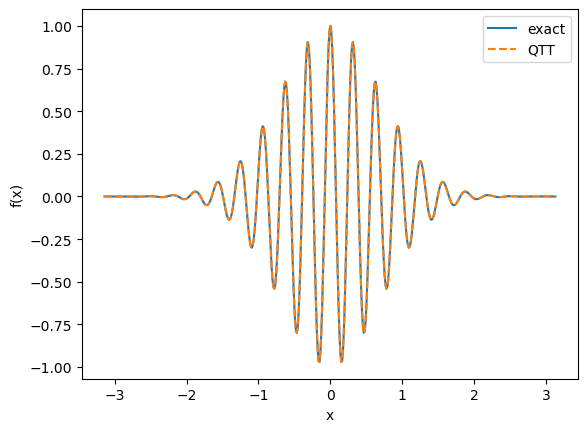

max abs error = 0.001345446589702426


In [6]:
xs = np.linspace(-np.pi, np.pi, 500, endpoint=False) # creating testing points.
f_exact = np.array([f1d(x) for x in xs])# forming exact values
f_qtt = np.array([qtt.eval([x]) for x in xs]) # evaluating QTT appoximations at each point. 
plt.plot(xs, f_exact, label="exact")
plt.plot(xs, f_qtt, "--", label="QTT")
plt.legend()
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()
print("max abs error = ", np.max(np.abs(f_exact - f_qtt)))

In [ ]:
b = 1.0
eta = 0.1
omega = 0.5

# DOS integrand 
def epsilon(kx, ky, kz, b=1.0):
    return -2.0 * b * (np.cos(kx) + np.cos(ky) + np.cos(kz))

# Lorentzian spectral function
def spectral_function(arg): # multidimensional QTensorCI function takes onyl one argument 
    kx, ky, kz = arg
    eps = epsilon(kx, ky, kz, b=b)
    return (1.0 / np.pi) * eta / ((omega - eps)**2 + eta**2)

R = 8  # each k dimension has 2^R points
qgrid = xfacpy.QuanticsGrid(a=-np.pi, b=np.pi, dim=3, nBit=R) # def. the grid 
args = xfacpy.TensorCI2Param() # parameter object for tensor cross interpolation
args.bondDim = 40  # max bond dimension 
ci = xfacpy.QTensorCI(f=spectral_function, qgrid=qgrid, args=args) # QTCI
max_sweeps = 40
for sweep in range(max_sweeps): # for 40 iterations, improve interpolation pivots.
    ci.iterate()
    print(f"sweep {sweep+1:2d}, pivot error = {ci.pivotError[-1]:.3e}")
    if ci.isDone():
        break

qtt = ci.get_qtt()
I_qtt = qtt.integral()
rho_qtt = I_qtt / (2.0 * np.pi)**3 #normalise
print("QTT integral =", I_qtt)
print("rho qtt =", rho_qtt)

# for more accuracy: 
# first set higher bond dimension, just after that set a higher partition R.

sweep  1, pivot error = 2.235e+00
sweep  2, pivot error = 3.118e-01
sweep  3, pivot error = 1.566e+00
sweep  4, pivot error = 6.126e-06
sweep  5, pivot error = 3.085e+00
QTT integral = 27.81553963366896
rho qtt = 0.11213672928416245
